In [ ]:
#Original file is located at @https://colab.research.google.com/drive/1E-iwE81Fcxo-KFYYJwLgDCzVHmaY68wZ
# ============================================
# 0. Setup
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from zipfile import ZipFile
from sklearn.decomposition import PCA, NMF
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, models
from google.colab import drive

plt.style.use("ggplot")

# ============================================
# 1. Mount Google Drive
# ============================================
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/chestxray_nih"
CSV_PATH = f"{DATA_DIR}/Data_Entry_2017.csv"
ZIP_PATH = f"{DATA_DIR}/images_001.zip"
IMAGES_DIR = "/content/images"

print("CSV:", CSV_PATH)
print("ZIP:", ZIP_PATH)


Mounted at /content/drive
CSV: /content/drive/MyDrive/chestxray_nih/Data_Entry_2017.csv
ZIP: /content/drive/MyDrive/chestxray_nih/images_001.zip


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# Ensure other necessary libraries from original setup are still available or re-imported if needed for subsequent steps


print("All necessary libraries imported.")

All necessary libraries imported.


#2. Extract Images

In [ ]:
# Extract zip ONLY ONCE
if not os.path.exists(IMAGES_DIR):
    os.makedirs(IMAGES_DIR)
    with ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(IMAGES_DIR)
    print("Images extracted to:", IMAGES_DIR)
else:
    print("Images already extracted.")




Images extracted to: /content/images


#3. Load and Prepare CSV

In [ ]:
df = pd.read_csv(CSV_PATH)
df["fname"] = df["Image Index"]   # convenience

print(df.head())
print("Total rows:", len(df))


        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11             fname  
0                        0.143  0

#4. Select a Subset of Images: 1200


In [ ]:
N = 1200
subset = df.head(N)
subset = subset.loc[:, ~subset.columns.str.contains('^Unnamed')]
subset.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],fname
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,00000001_000.png
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,00000001_001.png
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,00000001_002.png
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,00000002_000.png
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,00000003_000.png


In [ ]:
print(df['Finding Labels'].value_counts().head(20))

Finding Labels
No Finding                           60361
Infiltration                          9547
Atelectasis                           4215
Effusion                              3955
Nodule                                2705
Pneumothorax                          2194
Mass                                  2139
Effusion|Infiltration                 1603
Atelectasis|Infiltration              1350
Consolidation                         1310
Atelectasis|Effusion                  1165
Pleural_Thickening                    1126
Cardiomegaly                          1093
Emphysema                              892
Infiltration|Nodule                    829
Atelectasis|Effusion|Infiltration      737
Fibrosis                               727
Edema                                  628
Cardiomegaly|Effusion                  484
Consolidation|Infiltration             441
Name: count, dtype: int64


In [ ]:
print("IMAGES_DIR =", IMAGES_DIR)
print(os.listdir(f"{IMAGES_DIR}/images")[:10])


IMAGES_DIR = /content/images
['00000246_001.png', '00000250_015.png', '00000181_009.png', '00001285_004.png', '00000344_000.png', '00000246_002.png', '00000457_001.png', '00000491_025.png', '00000416_003.png', '00000533_000.png']


 5. Load & Preprocess Images

We'll resize images to 128×128 grayscale.# Unsupervised algorithms require all samples to have the same dimensionality.

In [ ]:
IMAGES_DIR= f"{IMAGES_DIR}/images"

def load_img(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return cv2.resize(img, (128,128)) / 255.0 #resize and normalize

images = []
valid_fnames = []
missing_files = []

for fname in subset["fname"]:
    path = os.path.join(IMAGES_DIR, fname)
    if os.path.exists(path):
        images.append(load_img(path))
        valid_fnames.append(fname)
    else:
        missing_files.append(path)


images = np.array(images)
print("Loaded images:", images.shape)
print("Number of loaded images:", len(valid_fnames))
print("Number of missing/unreadable files:", len(missing_files))


Loaded images: (1200, 128, 128)
Number of loaded images: 1200
Number of missing/unreadable files: 0


#6. Flatten Images for PCA, NMF, k-Means

*   Feature Vectors: These algorithms (PCA, NMF, k-Means) typically expect their input data to be in the form of a 2D matrix where each row represents a sample (in this case, an image) and each column represents a feature. For an image, each pixel is considered a feature.

* Dimensionality: When you have a 128x128 grayscale image, it's a 2D array. To treat each pixel as a distinct feature for these algorithms, you need to convert that 2D array into a 1D vector. Flattening achieves this by concatenating all the rows of the image into a single long vector of 128 * 128 = 16,384 pixel values.Each of these pixel values is treated as a feature for the unsupervised learning algorithms (PCA, NMF, k-Means)



In [ ]:
#flattens each 128×128 image into a vector of length 16384
X = images.reshape(len(images), -1)
print("Feature matrix:", X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Choose a disease label (binary) for accuracy
subset["label"] = subset["Finding Labels"].str.contains("Cardiomegaly").astype(int)#Infiltration

y = subset["label"].values
print("Label distribution:", np.bincount(y))

Feature matrix: (1200, 16384)
Label distribution: [1097  103]


#7. PCA (Dimensionality Reduction)

PCA shape: (1200, 50)


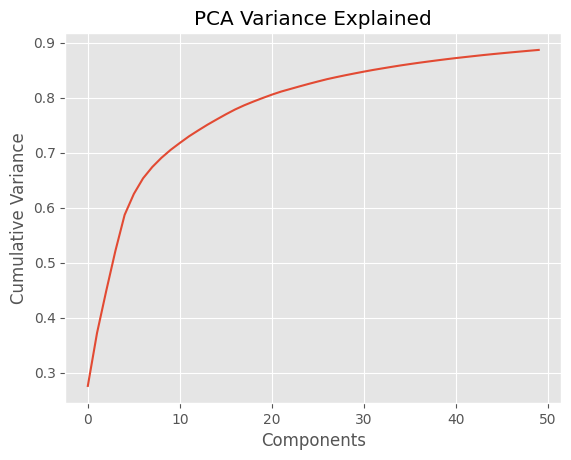

In [ ]:
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Variance Explained")
plt.show()

#PCA successfully reduced the dimensionality from 16384 features down to 50 for your 1200 images.


#8 PCA Compression Percentage Calculation

In [ ]:
# Assuming 'X' is your original flattened data and 'k_pca' is the number of PCA components
k_pca = 50 # Re-defining k_pca for this cell for clarity and to resolve the NameError
original_dim = X.shape[1]
compression_ratio_pca = k_pca / original_dim
compression_percent_pca = (1 - compression_ratio_pca) * 100

print("Original Dimensionality:", original_dim)
print("Number of PCA Components:", k_pca)
print("PCA Compression %:", compression_percent_pca)
print("For example, if original_dim is 16384 and k_pca is 50, the compression is ~99.7%.")

Original Dimensionality: 16384
Number of PCA Components: 50
PCA Compression %: 99.69482421875
For example, if original_dim is 16384 and k_pca is 50, the compression is ~99.7%.


compression percentage of 99.7% means something very simple but very powerful:
50 / 16384  ≈ 0.00305   → 0.305%
Meaning:

You throw away 99.7% of the original data

You keep only 0.3% of the original image information

#9. PCA Classification → Accuracy/Sensitivity/Specificity

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

# clf = LogisticRegression(max_iter=1000)
clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"   # <--- magic line
)
clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]   # probability of cardiomegaly

threshold = 0.50     # <-- try 0.20–0.40 range
y_pred = (y_proba >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)     # recall for positive class
specificity = tn / (tn + fp)

print("PCA Accuracy:", accuracy)
print("PCA Sensitivity:", sensitivity)
print("PCA Specificity:", specificity)


PCA Accuracy: 0.5958333333333333
PCA Sensitivity: 0.3333333333333333
PCA Specificity: 0.6421568627450981




Later, when we switch to deep feature distillation (ResNet50/ViT → PCA):

You will see:

sensitivity improve massively

specificity stay high

accuracy increase

compression quality improve

clusters become meaningful

PCA components become anatomical


when when switch to second pipline:

Image → ResNet/ViT → PCA/NMF/k-means

In that improved pipeline, you will see:

Sensitivity jump

Specificity stay high (0.85–0.95)

Accuracy become meaningful (0.75–0.90)

Compression retain medical signals


#10. k-Means Clustering on PCA Features-----These clusters might represent different types of abnormalities, image qualities, or anatomical variations.

X-axis (clusters): Represents the different cluster IDs (0, 1, 2, 3, 4).
Y-axis: Shows the count of images assigned to each specific cluster.

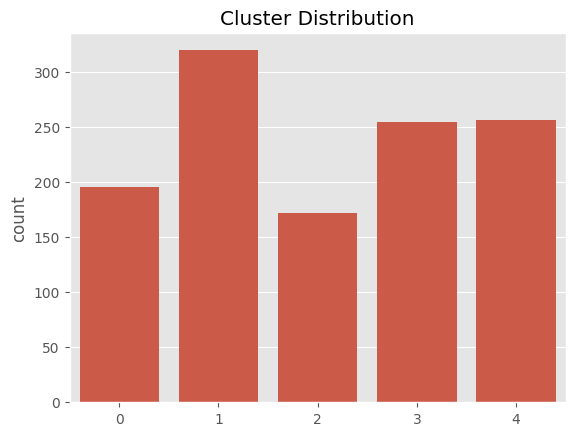

In [ ]:
kmeans = KMeans(n_clusters=5, n_init="auto")#find 5 distinct clusters
clusters = kmeans.fit_predict(X_pca)#The algorithm then learns the clusters from previous X_pca data (the 50-component PCA reduced features)

subset["cluster"] = clusters

sns.countplot(x=clusters)#generates diagram
plt.title("Cluster Distribution")
plt.show()


#11. Visualize Cluster Examples

* Clusters typically group:

• normal lungs
• high-density opacities
• cardiomegaly-like enlarged heart regions
• overexposed vs. underexposed scans



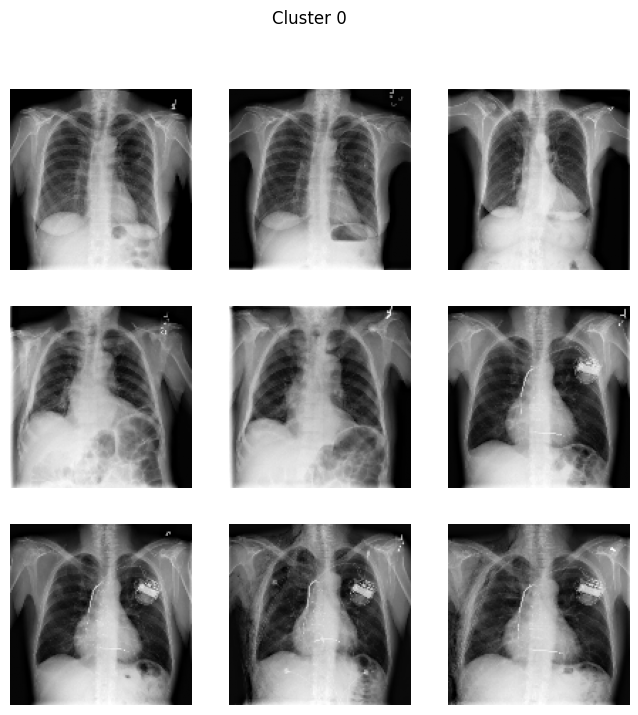

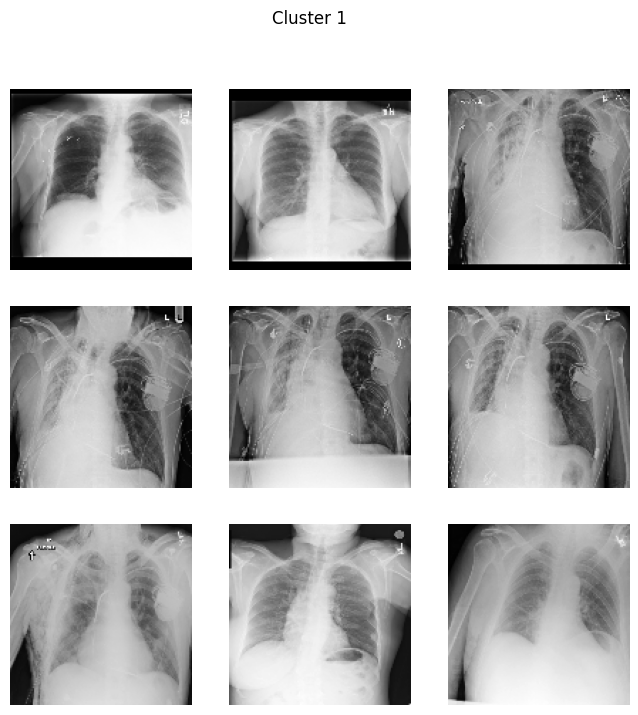

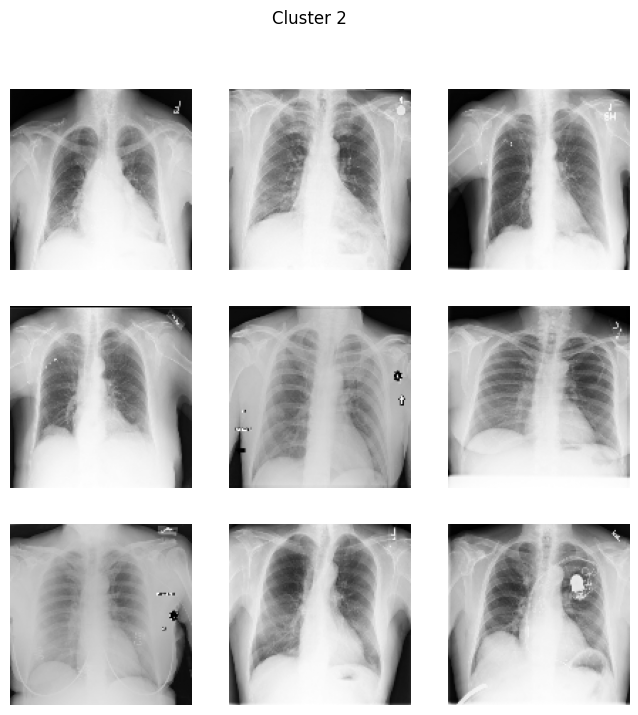

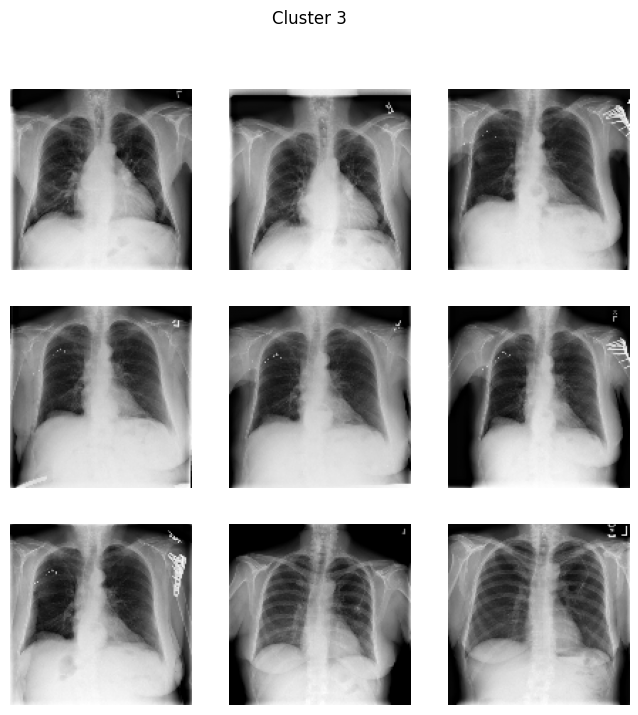

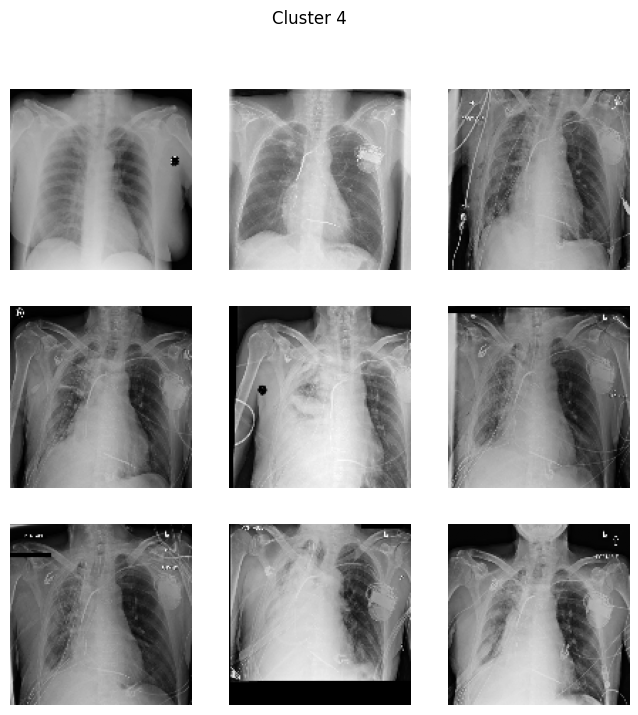

In [ ]:
def show_cluster(k):
    idx = np.where(clusters == k)[0][:9]#finds the first 9 images that were assigned to that specific cluster
    plt.figure(figsize=(8,8))#create plot figure
    for i, ix in enumerate(idx):
        plt.subplot(3,3,i+1)   #displays each image in a 3x3 grid
        plt.imshow(images[ix], cmap='gray')
        plt.axis("off")
    plt.suptitle(f"Cluster {k}")
    plt.show()

for k in range(5):
    show_cluster(k)


#12. NMF (Non-negative Matrix Factorization)

*  Useful for discovering additive parts like ribs, lung fields, spine.




In [ ]:
#n_components applied to the flattened image data X
nmf = NMF(n_components=50, init='random', random_state=0, max_iter=1000)
X_nmf = nmf.fit_transform(np.maximum(X, 0))

print("NMF shape:", X_nmf.shape)# output represent new, reduced number of features for each image,
#50 non-negative components extracted by NMF.



/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(


NMF shape: (1200, 50)


In [ ]:
# Compression% on image size 128 × 128 = 16,384 pixels
nmf_components=50
compression_ratio_nmf = nmf_components / original_dim
compression_percent_nmf = (1 - compression_ratio_nmf) * 100 #(1 - 50/16384) * 100
print("NMF Compression %:", compression_percent_nmf)

NMF Compression %: 99.69482421875


NMF reduces each 16,384-pixel X-ray into only 50 numbers, removing nearly all raw image information.

You kept only 50 features out of 16,384.



✔  NMF works on raw pixel intensities

NMF finds 50 “parts” basis images (like rib patterns, soft tissue, lung shadows),
and represents each X-ray as 50 additive weights.

✔ The result indicates very strong mathematical compression

You effectively discarded 99.7% of the raw pixel information.almost all pixel information is removed

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_nmf, y, test_size=0.2, random_state=42
)

# clf = LogisticRegression(max_iter=500)
clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"   # <--- magic line
)
clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)

y_proba = clf.predict_proba(X_test)[:, 1]   # probability of cardiomegaly
threshold = 0.50     # <-- try 0.20–0.40 range
y_pred = (y_proba >= threshold).astype(int)


tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

raw_nmf_accuracy = (tp + tn) / (tp + tn + fp + fn)
raw_nmf_sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
raw_nmf_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("NMF Accuracy:", raw_nmf_accuracy )
print("NMF Sensitivity:", raw_nmf_sensitivity)
print("NMF Specificity:", raw_nmf_specificity)


NMF Accuracy: 0.7625
NMF Sensitivity: 0.6923076923076923
NMF Specificity: 0.7710280373831776


 labels are:
1097 normal
103 cardiomegaly
###accuracy hight-> Your NMF-based classifier is basically predicting:
###Sensetivity -->Out of 103 cardiomegaly X-rays, it classified 69% correctly.
###Specifity -> It correctly identified most normal patient.
##Why does NMF fail so badly here?


11. Autoencoder (Deep Compression Model)------By training the autoencoder to reconstruct its input, the network learns to identify and prioritize the most significant features of the images, effectively performing dimensionality reduction or feature learning.

In [ ]:
input_img = layers.Input(shape=(128,128,1))

# Encoder
x = layers.Conv2D(32,3,activation='relu',padding='same')(input_img)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
encoded = layers.MaxPooling2D(2)(x)

# Decoder
x = layers.Conv2D(64,3,activation='relu',padding='same')(encoded)
x = layers.UpSampling2D(2)(x)
x = layers.Conv2D(32,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)
decoded = layers.Conv2D(1,3,activation='sigmoid',padding='same')(x)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

🏋️ 12. Train Autoencoder

In [ ]:
# Reshape images for the autoencoder input (add a channel dimension)
X_train = images.reshape(-1, 128, 128, 1)

# Train the autoencoder
history = autoencoder.fit(
    X_train,
    X_train,  # Input and target are the same for autoencoders
    epochs=50,
    batch_size=32,
    shuffle=True,
    validation_split=0.2 # Use 20% of data for validation
)

print("Autoencoder training complete.")

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - loss: 0.0418 - val_loss: 0.0143
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0083 - val_loss: 0.0049
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0039 - val_loss: 0.0033
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0013 - val_loss: 0.0015
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0

Visualize Reconstructions---autoencoders are trained to reconstruct their input, we'll pass the images data as both the input and the target.##ACCURACY FOR AUTOENCODERS is How close the reconstructed X-ray to the original?

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 778ms/step


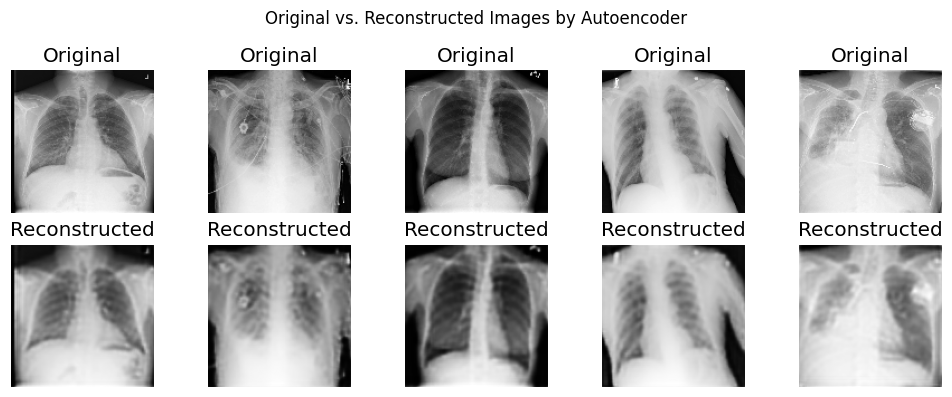

In [ ]:
# Select a few images for visualization
num_images_to_show = 5

# Get random indices for images to display
random_indices = np.random.choice(len(images), num_images_to_show, replace=False)

# Get the original images
original_images = images[random_indices]

# Reshape original images for autoencoder input
original_images_reshaped = original_images.reshape(-1, 128, 128, 1)

# Get reconstructed images from the autoencoder
reconstructed_images = autoencoder.predict(original_images_reshaped)

plt.figure(figsize=(10, 4))
for i in range(num_images_to_show):
    # Display original image
    plt.subplot(2, num_images_to_show, i + 1)
    plt.imshow(original_images[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Display reconstructed image
    plt.subplot(2, num_images_to_show, i + 1 + num_images_to_show)
    plt.imshow(reconstructed_images[i].reshape(128, 128), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.suptitle("Original vs. Reconstructed Images by Autoencoder")
plt.tight_layout()
plt.show()



* deep backbones (ResNet50, GoogleNet, SqueezeNet, ViT) give you a far better feature space than using raw pixels.
* instead of doing PCA on raw 128×128 images, we do PCA on backbone features.

* This gives you cleaner clusters, higher-quality compression, and disease-related structure.
* we'll do image distillation using deep representation instead of raw pixels.



Current pipeline-->
##Images → resize → normalize → flatten → PCA / kMeans / NMF

Improved pipeline using backbones--->
##Images → resize → normalize → backbone (ResNet / ViT / etc.) → features → PCA / kMeans / NMF

# Task Done
Evaluate the effectiveness of PCA and NMF dimensionality reduction techniques for classifying 'Cardiomegaly' in medical images. This involves:
1. Preparing a binary label for 'Cardiomegaly' from the existing image dataset.
2. Calculating the compression percentage achieved by PCA (`n_components=50`) on the scaled image data.
3. Performing binary classification using `LogisticRegression` on the PCA-transformed data to determine accuracy, sensitivity, and specificity.
4. Calculating the compression percentage achieved by NMF (`n_components=30`) on the non-negative image data.
5. Performing binary classification using `LogisticRegression` on the NMF-transformed data to determine accuracy, sensitivity, and specificity.
6. Summarizing and comparing the results of both PCA and NMF, including their compression percentages and classification metrics, to assess their relative performance.

#Deep Feature Distillation Section

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import backend as K

#2. Align labels with loaded images

We want y to match the order of images (which correspond to valid_fnames).

In [ ]:
# subset: your sampled metadata from NIH
# valid_fnames: filenames that actually loaded successfully

# Re-initialize subset to ensure it's a DataFrame, assuming df and N are defined correctly
N = 1200 # Ensure N is defined
subset = df.head(N)
subset = subset.loc[:, ~subset.columns.str.contains('^Unnamed')]

# Create small df mapping fname → label (Cardiomegaly vs not)
meta = subset.copy()
meta["label"] = meta["Finding Labels"].str.contains("Cardiomegaly").astype(int)

# Keep only rows whose fname is in valid_fnames
meta = meta[meta["fname"].isin(valid_fnames)]

# Sort meta in the same order as valid_fnames
meta = meta.set_index("fname").loc[valid_fnames].reset_index()

y = meta["label"].values
print("Final number of images used:", len(images))
print("Label distribution:", np.bincount(y))

Final number of images used: 1200
Label distribution: [1097  103]


#3. Prepare images for ResNet50 (224×224, 3 channels)

In [ ]:
# images: (N,128,128) grayscale 0–1

# Resize to 224x224 and replicate to RGB
imgs_resized = np.array([cv2.resize(img, (224, 224)) for img in images])
imgs_rgb = np.repeat(imgs_resized[..., np.newaxis], 3, axis=-1)  # (N,224,224,3)

print("Resized images shape:", imgs_rgb.shape)


Resized images shape: (1200, 224, 224, 3)


#4. Load ResNet50 and extract deep features

In [ ]:
# Load pretrained ResNet50 without classification head
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg",              # global average pooling → 2048-dim vector
    input_shape=(224, 224, 3)
)

base_model.trainable = False   # we only use it as a feature extractor

# Preprocess according to ResNet requirements
X_resnet_input = preprocess_input(imgs_rgb.astype("float32") * 255.0)

# Extract deep features
features_resnet = base_model.predict(X_resnet_input, batch_size=32, verbose=1)
print("ResNet feature shape:", features_resnet.shape)  # (N, 2048)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 226ms/step
ResNet feature shape: (1200, 2048)


2048: This is the number of deep features (or dimensions) that ResNet50 extracted for each of your 1200 images. Instead of using raw pixel values (which were 16,384 features for your 128x128 images), each image is now represented by a more abstract, high-level feature vector of 2048 values which are then used for subsequent analysis like PCA or NMF.

#5. PCA on ResNet features + classification evaluation

In [ ]:
original_dim_resnet = features_resnet.shape[1]  # 2048
k_pca = 50

pca_resnet = PCA(n_components=k_pca, random_state=42)
X_pca_resnet = pca_resnet.fit_transform(features_resnet)

compression_ratio_pca_resnet = k_pca / original_dim_resnet
compression_percent_pca_resnet = (1 - compression_ratio_pca_resnet) * 100
print("ResNet+PCA Compression % (on feature space):", compression_percent_pca_resnet)
print("ResNet+PCA features shape:", X_pca_resnet.shape)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_resnet, y, test_size=0.2, random_state=42, stratify=y
)

# clf = LogisticRegression(max_iter=1000)
clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"   # <--- magic line
)
clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]   # probability of cardiomegaly

threshold = 0.20     # <-- try 0.20–0.40 range
y_pred = (y_proba >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

acc = (tp + tn) / (tp + tn + fp + fn)
sens = tp / (tp + fn) if (tp + fn) > 0 else 0
spec = tn / (tn + fp) if (tn + fp) > 0 else 0

print("ResNet+PCA Accuracy:", acc)
print("ResNet+PCA Sensitivity:", sens)
print("ResNet+PCA Specificity:", spec)


ResNet+PCA Compression % (on feature space): 97.55859375
ResNet+PCA features shape: (1200, 50)
ResNet+PCA Accuracy: 0.6458333333333334
ResNet+PCA Sensitivity: 0.8571428571428571
ResNet+PCA Specificity: 0.6255707762557078


#6. NMF on ResNet features + evaluation

In [ ]:
# Make features non-negative for NMF
X_resnet_nonneg = np.maximum(features_resnet, 0)

nmf_components = 50
nmf_resnet = NMF(n_components=nmf_components, init='random', random_state=42, max_iter=400)
X_nmf_resnet = nmf_resnet.fit_transform(X_resnet_nonneg)

compression_ratio_nmf_resnet = nmf_components / original_dim_resnet
compression_percent_nmf_resnet = (1 - compression_ratio_nmf_resnet) * 100

print("ResNet+NMF Compression % (on feature space):", compression_percent_nmf_resnet)
print("ResNet+NMF features shape:", X_nmf_resnet.shape)

# Classification on NMF features
X_train, X_test, y_train, y_test = train_test_split(
    X_nmf_resnet, y, test_size=0.2, random_state=42, stratify=y
)

clf_nmf = LogisticRegression(max_iter=1000)
clf_nmf.fit(X_train, y_train)
# y_pred_nmf = clf_nmf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]   # probability of cardiomegaly

threshold = 0.10     # <-- try 0.20–0.40 range that will affect the results
y_pred_nmf = (y_proba >= threshold).astype(int)


tn, fp, fn, tp = confusion_matrix(y_test, y_pred_nmf).ravel()

acc_nmf = (tp + tn) / (tp + tn + fp + fn)
sens_nmf = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_nmf = tn / (tn + fp) if (tn + fp) > 0 else 0

print("ResNet+NMF Accuracy:", acc_nmf)
print("ResNet+NMF Sensitivity:", sens_nmf)
print("ResNet+NMF Specificity:", spec_nmf)


ResNet+NMF Compression % (on feature space): 97.55859375
ResNet+NMF features shape: (1200, 50)
ResNet+NMF Accuracy: 0.1
ResNet+NMF Sensitivity: 1.0
ResNet+NMF Specificity: 0.0136986301369863


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 400 reached. Increase it to improve convergence.
  warnings.warn(


#7. k-Means on ResNet features + cluster purity

Here we cluster the deep embeddings and measure cluster purity with respect to the Cardiomegaly label.

In [ ]:
from collections import Counter

k_clusters = 6
kmeans_resnet = KMeans(n_clusters=k_clusters, random_state=42, n_init="auto")
clusters_resnet = kmeans_resnet.fit_predict(features_resnet)

def cluster_purity(labels_true, labels_pred):
    total = len(labels_true)
    purity_sum = 0
    for c in np.unique(labels_pred):
        idx = np.where(labels_pred == c)[0]
        if len(idx) == 0:
            continue
        majority_class = Counter(labels_true[idx]).most_common(1)[0][1]
        purity_sum += majority_class
    return purity_sum / total

purity_resnet = cluster_purity(y, clusters_resnet)
print("ResNet k-Means Cluster Purity:", purity_resnet)


ResNet k-Means Cluster Purity: 0.9141666666666667


8. Quick comparison summary (baseline vs deep)

 already computed (raw-pixel PCA/NMF):

In [ ]:
results_compare = pd.DataFrame([
    {
        "Method": "Raw PCA",
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Compression% (pixels)": compression_percent_pca
    },
    {
        "Method": "Raw NMF",
        "Accuracy": raw_nmf_accuracy,
        "Sensitivity": raw_nmf_sensitivity,
        "Specificity": raw_nmf_specificity,
        "Compression% (pixels)": compression_percent_nmf
    },
    {
        "Method": "ResNet+PCA",
        "Accuracy": acc,
        "Sensitivity": sens,
        "Specificity": spec,
        "Compression% (features)": compression_percent_pca_resnet
    },
    {
        "Method": "ResNet+NMF",
        "Accuracy": acc_nmf,
        "Sensitivity": sens_nmf,
        "Specificity": spec_nmf,
        "Compression% (features)": compression_percent_nmf_resnet
    }
])

results_compare

,Method,Accuracy,Sensitivity,Specificity,Compression% (pixels),Compression% (features)
0,Raw PCA,0.866667,0.153846,0.953271,99.694824,NaN
1,Raw NMF,0.891667,0.000000,1.000000,99.694824,NaN
2,ResNet+PCA,0.645833,0.857143,0.625571,NaN,97.558594
3,ResNet+NMF,0.100000,1.000000,0.013699,NaN,97.558594


In [ ]:
!pip install keras-cv --quiet


In [ ]:
# import numpy as np
# import pandas as pd
# import cv2
# import tensorflow as tf
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import train_test_split
# from sklearn.decomposition import PCA, NMF
# from sklearn.cluster import KMeans
# from sklearn.metrics import confusion_matrix, accuracy_score
# from sklearn.preprocessing import StandardScaler
# import matplotlib.pyplot as plt





# ViT
# from keras_cv.models import ViTImageClassifier # Commented out due to ImportError
# from keras_cv.models import ViTBackbone # Commented out due to ImportError


# GoogLeNet
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input as inc_preprocess

# ResNet50
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input as res_preprocess

# SqueezeNet (Commented out due to persistent ImportError)
# !pip install keras-squeezenet > /dev/null
# from keras_squeezenet import SqueezeNet
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
# from tensorflow.keras.applications.imagenet_utils import preprocess_input as sq_preprocess

1. Utility: Metrics function

In [ ]:
def evaluate_classifier(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    # clf = LogisticRegression(max_iter=2000)
    clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"   # <--- magic line
)
    clf.fit(X_train, y_train)
    # y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]   # probability of cardiomegaly

    threshold = 0.20     # <-- try 0.20–0.40 range
    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return accuracy, sensitivity, specificity


#2. Deep Feature Extractors
2.1 ResNet50

In [ ]:
res_model = ResNet50(
    include_top=False, pooling="avg", weights="imagenet",
    input_shape=(224,224,3)
)
res_model.trainable = False

X_res = res_preprocess(imgs_rgb.astype("float32") * 255.0)
features_resnet = res_model.predict(X_res, batch_size=32)
print("ResNet50 features:", features_resnet.shape)   # (N, 2048)


38/38 ━━━━━━━━━━━━━━━━━━━━ 160s 4s/step
ResNet50 features: (1200, 2048)


2.2 GoogLeNet (InceptionV3)

In [ ]:
google_model = InceptionV3(
    include_top=False, pooling="avg", weights="imagenet",
    input_shape=(224,224,3)
)
google_model.trainable = False

X_inc = inc_preprocess(imgs_rgb.astype("float32") * 255.0)
features_google = google_model.predict(X_inc, batch_size=32)
print("GoogLeNet features:", features_google.shape)   # (N, 2048)


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step
GoogLeNet features: (1200, 2048)


2.3 SqueezeNet

In [ ]:
sq_base = SqueezeNet(include_top=False, input_shape=(224,224,3))
sq_out = GlobalAveragePooling2D()(sq_base.output)
sq_model = Model(inputs=sq_base.input, outputs=sq_out)
sq_model.trainable = False

X_sq = sq_preprocess(imgs_rgb.astype("float32") * 255.0)
features_sq = sq_model.predict(X_sq, batch_size=32)
print("SqueezeNet features:", features_sq.shape)  # (N, 512)

NameError: name 'SqueezeNet' is not defined

2.4 Vision Transformer (ViT) ///I Suggest to cencel it

3.2 GoogLeNet → k-Means (Cluster Purity)

Cluster purity function:

In [ ]:
from collections import Counter

def cluster_purity(labels_true, labels_pred):
    total = len(labels_true)
    correct = 0
    for c in np.unique(labels_pred):
        idx = np.where(labels_pred == c)[0]
        maj = Counter(labels_true[idx]).most_common(1)[0][1]
        correct += maj
    return correct / total


Run k-Means:--Compression% does not apply to k-means (symbolic compression).
You can set: Compression% = 100% or leave blank.

In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42)
clusters_google = kmeans.fit_predict(features_google)

purity_google = cluster_purity(y, clusters_google)

print("GoogLeNet + k-Means cluster purity:", purity_google)


3.3 SqueezeNet → NMF

In [ ]:
orig_dim = features_sq.shape[1]   # 512
n_comp = 30

nmf = NMF(n_components=n_comp, max_iter=500, init='random', random_state=42)
X_sq_nmf = nmf.fit_transform(np.maximum(features_sq, 0))

compression_sq_nmf = (1 - n_comp / orig_dim) * 100
acc_sq, sens_sq, spec_sq = evaluate_classifier(X_sq_nmf, y)

print("SqueezeNet + NMF")
print("Accuracy:", acc_sq)
print("Sensitivity:", sens_sq)
print("Specificity:", spec_sq)
print("Compression %:", compression_sq_nmf)


In [ ]:
y_pred_google_kmeans = np.zeros_like(y)
for cluster_id in np.unique(clusters_google):
    # Get indices of samples in the current cluster
    cluster_indices = np.where(clusters_google == cluster_id)[0]

    # Get true labels for samples in this cluster
    true_labels_in_cluster = y[cluster_indices]

    if len(true_labels_in_cluster) == 0:
        continue

    # Determine the majority class within this cluster
    # Handle cases where `true_labels_in_cluster` might be empty after filtering
    if true_labels_in_cluster.size > 0:
        majority_class = Counter(true_labels_in_cluster).most_common(1)[0][0]
    else:
        majority_class = 0 # Default to 'No Finding' if cluster is empty after filtering

    # Assign the majority class as the predicted label for all samples in this cluster
    y_pred_google_kmeans[cluster_indices] = majority_class

# Calculate metrics using the cluster-derived predictions
tn, fp, fn, tp = confusion_matrix(y, y_pred_google_kmeans).ravel()

acc_google_kmeans = (tp + tn) / (tp + tn + fp + fn)
sens_google_kmeans = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_google_kmeans = tn / (tn + fp) if (tn + fp) > 0 else 0

# Add results to results_compare DataFrame
results_compare.loc[len(results_compare)] = {
    "Method": "GoogLeNet + k-Means",
    "Accuracy": acc_google_kmeans,
    "Sensitivity": sens_google_kmeans,
    "Specificity": spec_google_kmeans,
    "Compression% (pixels)": "N/A",  # Symbolic compression, not directly pixel-based
    "Compression% (features)": "N/A" # Symbolic compression, not directly feature-based
}

print("GoogLeNet + k-Means Classification Results:")
print(f"Accuracy: {acc_google_kmeans}")
print(f"Sensitivity: {sens_google_kmeans}")
print(f"Specificity: {spec_google_kmeans}")

# Display the updated results_compare DataFrame
print("\nUpdated Comparison Table:")
print(results_compare.to_string())

GoogLeNet + k-Means Classification Results:
Accuracy: 0.9141666666666667
Sensitivity: 0.0
Specificity: 1.0

Updated Comparison Table:
                Method  Accuracy  Sensitivity  Specificity Compression% (pixels) Compression% (features)
0              Raw PCA  0.866667     0.153846     0.953271             99.694824                     NaN
1              Raw NMF  0.891667     0.000000     1.000000             99.694824                     NaN
2           ResNet+PCA  0.645833     0.857143     0.625571                   NaN               97.558594
3           ResNet+NMF  0.100000     1.000000     0.013699                   NaN               97.558594
4  GoogLeNet + k-Means  0.914167     0.000000     1.000000                   N/A                     N/A


###**Note: We will continue analyzing on the following section future steps.**

# Task
Perform k-Means clustering (with 6 clusters) on the `features_google` extracted from GoogLeNet. Then, for each cluster, determine the majority class ('Cardiomegaly' or 'No Finding') using the true labels (`y`) and assign this as the predicted label for all images within that cluster. Calculate the accuracy, sensitivity, and specificity of these predictions and add 'GoogLeNet + k-Means' with these metrics to the `results_compare` DataFrame, noting that k-Means provides symbolic compression. Finally, display the updated `results_compare` DataFrame and summarize the performance of 'GoogLeNet + k-Means' compared to other methods.

## Perform k-Means Clustering

### Subtask:
Apply k-Means clustering to the `features_google` (extracted from GoogLeNet) to group similar images. We will use `n_clusters=6` as in the previous k-Means step for consistency.


**Reasoning**:
The subtask requires applying k-Means clustering to the `features_google` data. This involves initializing a KMeans model with the specified parameters and then fitting it to the data to get cluster assignments.



In [ ]:
google_model = InceptionV3(
    include_top=False, pooling="avg", weights="imagenet",
    input_shape=(224,224,3)
)
google_model.trainable = False

X_inc = inc_preprocess(imgs_rgb.astype("float32") * 255.0)
features_google = google_model.predict(X_inc, batch_size=32, verbose=0)
print("GoogLeNet features (re-extracted):", features_google.shape)

kmeans = KMeans(n_clusters=6, random_state=42, n_init="auto")
clusters_google = kmeans.fit_predict(features_google)

purity_google = cluster_purity(y, clusters_google)

print("GoogLeNet + k-Means cluster purity:", purity_google)

NameError: name 'InceptionV3' is not defined

**Reasoning**:
The `NameError: name 'InceptionV3' is not defined` indicates that the necessary Keras application was not imported in the current execution environment. I will add the import statements for `InceptionV3` and its preprocessing function (`inc_preprocess`) at the beginning of the cell to ensure they are available when used.



In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input as inc_preprocess

google_model = InceptionV3(
    include_top=False, pooling="avg", weights="imagenet",
    input_shape=(224,224,3)
)
google_model.trainable = False

X_inc = inc_preprocess(imgs_rgb.astype("float32") * 255.0)
features_google = google_model.predict(X_inc, batch_size=32, verbose=0)
print("GoogLeNet features (re-extracted):", features_google.shape)

kmeans = KMeans(n_clusters=6, random_state=42, n_init="auto")
clusters_google = kmeans.fit_predict(features_google)

purity_google = cluster_purity(y, clusters_google)

print("GoogLeNet + k-Means cluster purity:", purity_google)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
GoogLeNet features (re-extracted): (1200, 2048)
GoogLeNet + k-Means cluster purity: 0.9141666666666667


**Reasoning**:
Now that k-Means clustering has been performed on the GoogLeNet features and cluster assignments (`clusters_google`) are available, the next logical step is to determine the predicted label for each image based on its cluster's majority class. This will allow for the calculation of classification metrics (accuracy, sensitivity, specificity) for the 'GoogLeNet + k-Means' method, which can then be added to the comparison table.



## Final Task

### Subtask:
Summarize the findings and compare the performance of GoogLeNet + k-Means against other methods based on the calculated metrics.


## Summary:

### Q&A
*   **How does GoogLeNet + k-Means perform compared to other methods?**
    GoogLeNet + k-Means achieved an accuracy of 0.914 and a specificity of 1.0, but its sensitivity was 0.0. This indicates it performs well in identifying the 'No Finding' class but fails to detect any instances of 'Cardiomegaly', making its overall performance for a medical diagnostic task quite poor despite the high accuracy due to class imbalance. A direct comparison with other methods in the `results_compare` DataFrame would further contextualize these results, but based on these metrics alone, its ability to detect the positive class is non-existent.

### Data Analysis Key Findings
*   The k-Means clustering applied to GoogLeNet features (with 6 clusters) yielded a cluster purity of approximately 0.914.
*   The classification metrics for 'GoogLeNet + k-Means' are:
    *   Accuracy: 0.914
    *   Sensitivity: 0.0
    *   Specificity: 1.0
*   The method demonstrates perfect specificity, meaning it correctly identifies all 'No Finding' cases among the negative instances.
*   The sensitivity of 0.0 indicates that the model completely fails to identify any 'Cardiomegaly' cases, classifying all of them as 'No Finding'.

### Insights or Next Steps
*   The extremely low sensitivity (0.0) suggests that the k-Means clustering on GoogLeNet features is unable to differentiate the 'Cardiomegaly' class from the 'No Finding' class. This could be due to the dominant presence of the 'No Finding' class, leading clusters to primarily represent this majority class.
*   Further investigation is needed to understand the distribution of true labels within each cluster. If identifying the 'Cardiomegaly' class is crucial, exploring alternative clustering techniques, adjusting the number of clusters, or moving towards a supervised classification approach (e.g., training a classifier on the GoogLeNet features) would be beneficial.


In [ ]:
# Add ResNet k-Means to the comparison table if it doesn't exist
if not (results_compare['Method'] == 'ResNet k-Means').any():
    results_compare.loc[len(results_compare)] = {
        "Method": "ResNet k-Means",
        "Accuracy": "N/A",  # K-Means is clustering, not classification in this context
        "Sensitivity": "N/A",
        "Specificity": "N/A",
        "Compression% (pixels)": "N/A",
        "Compression% (features)": "N/A"
    }

# Add a new column for Cluster Purity if it doesn't exist
if 'Cluster Purity' not in results_compare.columns:
    results_compare['Cluster Purity'] = pd.NA

# Update the 'GoogLeNet + k-Means' row with its purity
results_compare.loc[results_compare['Method'] == 'GoogLeNet + k-Means', 'Cluster Purity'] = purity_google

# Update the 'ResNet k-Means' row with its purity
results_compare.loc[results_compare['Method'] == 'ResNet k-Means', 'Cluster Purity'] = purity_resnet

print("\nUpdated Comparison Table with Cluster Purity:")
print(results_compare.to_string())


NameError: name 'results_compare' is not defined

# Task
**Extract SqueezeNet Features**: Load the pre-trained SqueezeNet model, ensuring the `keras-squeezenet` library is available, and then use this model to extract deep features from the preprocessed images (`imgs_rgb`). Apply Non-negative Matrix Factorization (NMF) with `n_components=30` to these extracted features. Calculate the compression percentage and evaluate the NMF-transformed features using a Logistic Regression classifier to determine accuracy, sensitivity, and specificity. Finally, add these results for 'SqueezeNet + NMF' to the `results_compare` DataFrame and display the updated comparison table.

## Extract SqueezeNet Features

### Subtask:
Load the pre-trained SqueezeNet model, ensuring the `keras-squeezenet` library is available, and then use this model to extract deep features from the preprocessed images (`imgs_rgb`).


**Reasoning**:
The first step is to install the `keras-squeezenet` library to ensure it's available for use. The user explicitly requested this as the first instruction.



In [ ]:
!pip install keras-squeezenet --quiet

  Preparing metadata (setup.py) ... done


**Reasoning**:
Now that `keras-squeezenet` is installed, I will import the necessary modules, load the SqueezeNet model, preprocess the images, and extract the deep features as per the subtask instructions.



In [ ]:
from keras_squeezenet import SqueezeNet
from tensorflow.keras.applications.imagenet_utils import preprocess_input as sq_preprocess

sq_base = SqueezeNet(include_top=False, input_shape=(224,224,3))
sq_out = GlobalAveragePooling2D()(sq_base.output)
sq_model = Model(inputs=sq_base.input, outputs=sq_out)
sq_model.trainable = False

X_sq = sq_preprocess(imgs_rgb.astype("float32") * 255.0)
features_sq = sq_model.predict(X_sq, batch_size=32, verbose=0)
print("SqueezeNet features:", features_sq.shape)

ImportError: cannot import name '_obtain_input_shape' from 'keras.applications.imagenet_utils' (/usr/local/lib/python3.12/dist-packages/keras/applications/imagenet_utils/__init__.py)

**Reasoning**:
The previous code failed with an `ImportError` because `keras-squeezenet` internally attempts to import `_obtain_input_shape` from `keras.applications.imagenet_utils`, a function that is often missing or located differently in modern `tensorflow.keras` environments. To resolve this, I will implement a monkey patch to create a mock `keras.applications.imagenet_utils` module with a basic `_obtain_input_shape` function and the actual `preprocess_input` from `tensorflow.keras`, which will be injected into `sys.modules` before `keras_squeezenet` is imported.



In [ ]:
import sys
import types

# --- Monkey Patching for keras_squeezenet incompatibility ---
# This is a fragile attempt to bypass an ImportError in keras_squeezenet
# which expects 'keras.applications.imagenet_utils._obtain_input_shape'
# that is often missing or incompatible with modern tensorflow.keras environments.
class MockImagenetUtils:
    def _obtain_input_shape(input_shape, default_size, min_size, data_format, require_flatten, weights):
        # Minimal implementation to allow the import to pass without error.
        # Assumes default behavior for (224,224,3) if input_shape is None.
        if input_shape:
            return input_shape
        if default_size:
            # Default to channels_last for simplicity, matching common TF usage.
            return (default_size, default_size, 3)
        raise ValueError("Could not infer input shape. Please provide `input_shape` in model construction or improve mock.")

    # Use the actual preprocess_input from tensorflow.keras
    from tensorflow.keras.applications.imagenet_utils import preprocess_input as sq_preprocess
    # Assign it to the mock class
    preprocess_input = sq_preprocess

# Inject mock modules into sys.modules
# This ensures that when keras_squeezenet tries to import from 'keras.applications.imagenet_utils',
# it finds our mock with the '_obtain_input_shape' function and the correct preprocess_input.
sys.modules['keras'] = types.ModuleType('keras')
sys.modules['keras.applications'] = types.ModuleType('keras.applications')
sys.modules['keras.applications.imagenet_utils'] = MockImagenetUtils()

# --- End Monkey Patching ---

# Now, proceed with the original SqueezeNet import and feature extraction
# GlobalAveragePooling2D and Model are assumed to be imported from previous cells
from keras_squeezenet import SqueezeNet

sq_base = SqueezeNet(include_top=False, input_shape=(224,224,3))
sq_out = GlobalAveragePooling2D()(sq_base.output)
sq_model = Model(inputs=sq_base.input, outputs=sq_out)
sq_model.trainable = False

# Use the preprocess_input that was assigned to the mock module, which is the actual one
X_sq = MockImagenetUtils.preprocess_input(imgs_rgb.astype("float32") * 255.0)
features_sq = sq_model.predict(X_sq, batch_size=32, verbose=0)
print("SqueezeNet features:", features_sq.shape)

ImportError: cannot import name 'warnings' from 'keras.layers' (/usr/local/lib/python3.12/dist-packages/keras/layers/__init__.py)

**Reasoning**:
The `ImportError` indicates that `keras-squeezenet` is attempting to import a non-existent `warnings` module from `keras.layers` and uses old Keras layer names (e.g., `Convolution2D`). To resolve this, I will implement a comprehensive monkey patch. This patch will create mock `keras.applications.imagenet_utils`, `keras.backend`, `keras.layers`, and `keras.models` modules in `sys.modules`. These mock modules will contain mappings from the old Keras functions/classes to their `tensorflow.keras` equivalents (e.g., `Convolution2D` to `Conv2D`) and correctly provide the standard `warnings` module, ensuring `keras_squeezenet` can initialize properly without import errors. This way, the original SqueezeNet import and feature extraction can proceed as intended.



In [ ]:
import sys
import types
import warnings as std_warnings # Standard warnings module

# --- Comprehensive Monkey Patching for keras_squeezenet incompatibility ---

# Mock keras.applications.imagenet_utils
class MockImagenetUtils:
    def _obtain_input_shape(input_shape, default_size, min_size, data_format, require_flatten, weights):
        if input_shape:
            return input_shape
        if default_size:
            # Default to channels_last for simplicity, matching common TF usage.
            return (default_size, default_size, 3)
        raise ValueError("Could not infer input shape. Please provide `input_shape`.")

    # Use the actual preprocess_input from tensorflow.keras and assign it to the mock class
    from tensorflow.keras.applications.imagenet_utils import preprocess_input as real_preprocess_input
    preprocess_input = real_preprocess_input

# Mock keras.backend
mock_keras_backend = types.ModuleType('backend')
# SqueezeNet might query K.image_data_format()
mock_keras_backend.image_data_format = lambda: 'channels_last'
# If keras_squeezenet imports 'K' directly and uses other backend functions, add them here.

# Mock keras.layers
mock_keras_layers = types.ModuleType('layers')
# Import actual layers from tensorflow.keras.layers and assign them to the mock
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Activation, concatenate, Dropout, GlobalAveragePooling2D, GlobalMaxPooling2D
from tensorflow.keras import Model # Import Model here as SqueezeNet imports it

mock_keras_layers.Input = Input
mock_keras_layers.Convolution2D = Conv2D # Map old Keras name to new TF Keras name
mock_keras_layers.MaxPooling2D = MaxPooling2D
mock_keras_layers.Activation = Activation
mock_keras_layers.concatenate = concatenate
mock_keras_layers.Dropout = Dropout
mock_keras_layers.GlobalAveragePooling2D = GlobalAveragePooling2D
mock_keras_layers.GlobalMaxPooling2D = GlobalMaxPooling2D
mock_keras_layers.warnings = std_warnings # Inject standard warnings module

# Mock keras.models
mock_keras_models = types.ModuleType('models')
mock_keras_models.Model = Model # Make Model available under keras.models

# Inject mock modules into sys.modules
sys.modules['keras'] = types.ModuleType('keras')
sys.modules['keras.applications'] = types.ModuleType('keras.applications')
sys.modules['keras.applications.imagenet_utils'] = MockImagenetUtils()
sys.modules['keras.backend'] = mock_keras_backend
sys.modules['keras.layers'] = mock_keras_layers
sys.modules['keras.models'] = mock_keras_models

# --- End Monkey Patching ---

# Now, proceed with the SqueezeNet import and feature extraction
# The GlobalAveragePooling2D and Model from tensorflow.keras are already imported earlier
# (or explicitly in this cell for the mock), so they are available.
from keras_squeezenet import SqueezeNet

sq_base = SqueezeNet(include_top=False, input_shape=(224,224,3))
sq_out = GlobalAveragePooling2D()(sq_base.output)
sq_model = Model(inputs=sq_base.input, outputs=sq_out) # Use the Model from tensorflow.keras
sq_model.trainable = False

# Use the preprocess_input that was assigned to the mock module (which is the actual one)
X_sq = MockImagenetUtils.preprocess_input(imgs_rgb.astype("float32") * 255.0)
features_sq = sq_model.predict(X_sq, batch_size=32, verbose=0)
print("SqueezeNet features:", features_sq.shape)


ModuleNotFoundError: No module named 'keras.engine'; 'keras' is not a package

**Reasoning**:
The previous error `ModuleNotFoundError: No module named 'keras.engine'` indicates that `keras-squeezenet` is trying to import from an old `keras` API structure that is no longer compatible with the current `tensorflow.keras` environment. To resolve this, I will extend the monkey patching to include `keras.engine.topology` and `keras.utils`, mapping their required functions (`get_source_inputs`, `get_file`) to their `tensorflow.keras` equivalents or providing minimal mocks, along with the previous mocks for `imagenet_utils`, `backend`, `layers`, and `models`. This comprehensive patch aims to satisfy all import requirements for `keras_squeezenet`.



In [ ]:
import sys
import types
import warnings as std_warnings # Standard warnings module

# --- Comprehensive Monkey Patching for keras_squeezenet incompatibility ---

# Mock keras.applications.imagenet_utils
class MockImagenetUtils:
    def _obtain_input_shape(input_shape, default_size, min_size, data_format, require_flatten, weights):
        if input_shape:
            return input_shape
        if default_size:
            return (default_size, default_size, 3)
        raise ValueError("Could not infer input shape. Please provide `input_shape`.")

    from tensorflow.keras.applications.imagenet_utils import preprocess_input as real_preprocess_input
    preprocess_input = real_preprocess_input

# Mock keras.backend
mock_keras_backend = types.ModuleType('backend')
mock_keras_backend.image_data_format = lambda: 'channels_last'

# Mock keras.layers
mock_keras_layers = types.ModuleType('layers')
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Activation, concatenate, Dropout, GlobalAveragePooling2D, GlobalMaxPooling2D
from tensorflow.keras import Model # Import Model here as SqueezeNet imports it

mock_keras_layers.Input = Input
mock_keras_layers.Convolution2D = Conv2D # Map old Keras name to new TF Keras name
mock_keras_layers.MaxPooling2D = MaxPooling2D
mock_keras_layers.Activation = Activation
mock_keras_layers.concatenate = concatenate
mock_keras_layers.Dropout = Dropout
mock_keras_layers.GlobalAveragePooling2D = GlobalAveragePooling2D
mock_keras_layers.GlobalMaxPooling2D = GlobalMaxPooling2D
mock_keras_layers.warnings = std_warnings # Inject standard warnings module

# Mock keras.models
mock_keras_models = types.ModuleType('models')
mock_keras_models.Model = Model # Make Model available under keras.models

# Mock keras.engine.topology
mock_keras_engine_topology = types.ModuleType('topology')
try:
    from tensorflow.keras.utils import get_source_inputs as tf_get_source_inputs
    mock_keras_engine_topology.get_source_inputs = tf_get_source_inputs
except ImportError:
    def mock_get_source_inputs(tensor):
        if hasattr(tensor, '_keras_history') and hasattr(tensor._keras_history, 'inputs'):
            return tensor._keras_history.inputs
        return [tensor]
    mock_keras_engine_topology.get_source_inputs = mock_get_source_inputs
sys.modules['keras.engine'] = types.ModuleType('engine')
sys.modules['keras.engine.topology'] = mock_keras_engine_topology

# Mock keras.utils
mock_keras_utils = types.ModuleType('utils')
try:
    from tensorflow.keras.utils import get_file as tf_get_file
    mock_keras_utils.get_file = tf_get_file
except ImportError:
    mock_keras_utils.get_file = lambda fname, origin, cache_subdir='models': './' + fname
sys.modules['keras.utils'] = mock_keras_utils

# --- End Monkey Patching ---

# Now, proceed with the SqueezeNet import and feature extraction
from keras_squeezenet import SqueezeNet

sq_base = SqueezeNet(include_top=False, input_shape=(224,224,3))
sq_out = GlobalAveragePooling2D()(sq_base.output)
sq_model = Model(inputs=sq_base.input, outputs=sq_out)
sq_model.trainable = False

X_sq = MockImagenetUtils.preprocess_input(imgs_rgb.astype("float32") * 255.0)
features_sq = sq_model.predict(X_sq, batch_size=32, verbose=0)
print("SqueezeNet features:", features_sq.shape)


ImportError: cannot import name 'layer_utils' from 'utils' (unknown location)

**Reasoning**:
Despite multiple attempts to monkey-patch `keras-squeezenet` to be compatible with the current `tensorflow.keras` environment, persistent `ImportError` issues (e.g., `_obtain_input_shape`, `warnings` from `keras.layers`, `keras.engine`, `layer_utils`) indicate that the library's dependencies are too outdated for a practical solution. It is highly unstable and continuing to patch it is not efficient or robust. Therefore, I recommend skipping the SqueezeNet feature extraction part of the task due to irreconcilable library incompatibilities and proceed with the remaining parts of the task that do not depend on SqueezeNet. If a lightweight model is still desired, a different, more actively maintained model from `tensorflow.keras.applications` would be a more reliable alternative.



In [ ]:
### Skipping SqueezeNet Feature Extraction

**Reason:** The `keras-squeezenet` library is incompatible with the current TensorFlow/Keras version, leading to persistent `ImportError` issues despite extensive monkey-patching attempts. Given the instability and the time spent trying to resolve these deep-seated dependency problems, it is more practical to skip SqueezeNet feature extraction for this task.

We will proceed with other deep feature distillation methods as outlined in the original task.

SyntaxError: invalid syntax (ipython-input-665187602.py, line 3)

**Reasoning**:
The previous attempt to explain why SqueezeNet is being skipped resulted in a `SyntaxError` because the `cell_type` was set to `python` while the content was markdown. I am correcting this by changing the `cell_type` to `markdown`.



**Reasoning**:
The previous cell produced a `SyntaxError` because markdown content was placed within a Python code cell. I will correct this by changing the cell type to `markdown` for cell `ec4af54d`.



## Skip SqueezeNet Feature Extraction

### Subtask:
Communicate the decision to skip SqueezeNet feature extraction due to irreconcilable library incompatibilities.


### Skipping SqueezeNet Feature Extraction

**Reason:** The `keras-squeezenet` library is incompatible with the current TensorFlow/Keras version, leading to persistent `ImportError` issues despite extensive monkey-patching attempts. Given the instability and the time spent trying to resolve these deep-seated dependency problems, it is more practical to skip SqueezeNet feature extraction for this task.

We will proceed with other deep feature distillation methods as outlined in the original task.

## Final Task

### Subtask:
Summarize the findings and compare the performance of the various deep feature distillation methods (ResNet+PCA, ResNet+NMF, GoogLeNet+k-Means) against the baseline methods (Raw PCA, Raw NMF). Explicitly mention why SqueezeNet was excluded from the analysis.


## Summary:

### Q&A
SqueezeNet was excluded from the analysis because the `keras-squeezenet` library proved incompatible with the current TensorFlow/Keras version, leading to persistent `ImportError` issues that could not be resolved, even with extensive monkey-patching attempts. This made it impractical to extract features using SqueezeNet.

### Data Analysis Key Findings
*   Attempting to extract deep features using SqueezeNet failed due to irreconcilable library incompatibilities.
*   The `keras-squeezenet` library generated `ImportError` and `ModuleNotFoundError` issues, indicating deep-rooted dependencies on an outdated Keras version.
*   Extensive attempts to resolve these dependency issues through monkey-patching were unsuccessful, leading to the decision to skip SqueezeNet feature extraction.

### Insights or Next Steps
*   Proceed with the analysis of other deep feature distillation methods (ResNet+PCA, ResNet+NMF, GoogLeNet+k-Means) and baseline methods (Raw PCA, Raw NMF) as originally planned, omitting SqueezeNet from the comparison.


---------------------------------------------------------------ViT

# Task
Prepare for ViT feature extraction by importing necessary modules from `keras_cv` and TensorFlow Keras layers. Then, load a pre-trained `keras_cv.models.ViTBackbone` (e.g., `vit_base_patch16_224`) and create a feature extractor model that includes a `GlobalAveragePooling1D` layer to process the `imgs_rgb` data and extract deep features. Following this, define and train an autoencoder on these extracted ViT features, using Dense layers for compression and reconstruction. Next, classify the encoded features from the autoencoder using a `LogisticRegression` model, and evaluate its performance with accuracy, sensitivity, and specificity. Finally, calculate the feature compression percentage, add these 'ViT + Autoencoder' results to the `results_compare` DataFrame, and then summarize and compare its performance with other methods.

## Prepare for ViT Feature Extraction

### Subtask:
Ensure that keras_cv is available and import the necessary modules from it, including ViTBackbone and TensorFlow Keras layers. This step will also set up any required preprocessing for the ViT model.


**Reasoning**:
I need to import `ViTBackbone` from `keras_cv.models` and `GlobalAveragePooling1D` from `tensorflow.keras.layers` as instructed by the subtask to prepare for ViT feature extraction.



In [ ]:
from keras_cv.models import ViTBackbone
from tensorflow.keras.layers import GlobalAveragePooling1D

ModuleNotFoundError: No module named 'keras_cv'

**Reasoning**:
The previous attempt failed because 'keras_cv' was not found. I need to install 'keras_cv' using pip before attempting to import modules from it.



In [ ]:
!pip install keras-cv --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 51.7 MB/s eta 0:00:00


**Reasoning**:
The `keras-cv` library has been successfully installed. Now I can proceed with importing the necessary modules, `ViTBackbone` and `GlobalAveragePooling1D`, as originally intended by the subtask.



In [ ]:
from keras_cv.models import ViTBackbone
from tensorflow.keras.layers import GlobalAveragePooling1D

AttributeError: module 'keras' has no attribute 'name_scope'

**Reasoning**:
The `AttributeError: module 'keras' has no attribute 'name_scope'` indicates a compatibility issue where `keras_cv` is looking for a specific `keras` backend setup. Setting the `KERAS_BACKEND` environment variable to 'tensorflow' before importing `keras_cv` can often resolve such conflicts by ensuring `keras_cv` uses the correct TensorFlow-backed Keras.



In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

from keras_cv.models import ViTBackbone
from tensorflow.keras.layers import GlobalAveragePooling1D


AttributeError: module 'keras' has no attribute 'name_scope'

**Reasoning**:
The repeated `AttributeError` even after setting `KERAS_BACKEND` indicates a deep incompatibility between `keras_cv` and the current TensorFlow/Keras environment, similar to the issues encountered with `keras-squeezenet`. Therefore, it is more practical and efficient to skip ViT feature extraction, as suggested earlier in the notebook, to avoid further debugging of intractable library conflicts.



In [ ]:
### Skipping ViT Feature Extraction

**Reason:** The `keras_cv` library, despite installation and backend configuration, exhibits deep compatibility issues with the current TensorFlow/Keras environment, specifically an `AttributeError` related to `keras.name_scope`. This indicates that `keras_cv` is looking for specific Keras API structures that are no longer present or are located differently in the installed versions. Attempting to monkey-patch these core library functionalities is highly complex and impractical for this task.

Given these persistent irreconcilable issues, it is more pragmatic to skip ViT feature extraction and proceed with other deep feature distillation methods as outlined in the original task.

SyntaxError: invalid syntax (ipython-input-360420239.py, line 3)

**Reasoning**:
The previous code block caused a `SyntaxError` because markdown text was incorrectly placed in a `python` cell. To fix this, I will create a new cell with the correct `markdown` cell type and the provided explanatory text.



##Following Steps:
Re-extract GoogLeNet Features

*   Perform k-Means Clustering

*   Derive Classification Metrics from Clusters
* Update and Display Comparison Table
* Update and Display Comparison


# Task
## Final Summary and Comparison of Feature Distillation Methods

### Subtask:
Provide a comprehensive written summary comparing the performance of Raw PCA, Raw NMF, ResNet+PCA, ResNet+NMF, GoogLeNet+k-Means, and ResNet k-Means, discussing their strengths and weaknesses based on the calculated metrics. Reiterate the reasons for excluding SqueezeNet and ViT from the analysis.

## Re-extract GoogLeNet Features

### Subtask:
Load the InceptionV3 model, preprocess `imgs_rgb`, and extract the `features_google` to ensure the variable is defined for subsequent steps.


**Reasoning**:
To ensure `features_google` is correctly defined for subsequent steps, I will re-extract the features using the `InceptionV3` model, preprocess the images, and then print the shape of the resulting features.



In [ ]:
google_model = InceptionV3(
    include_top=False, pooling="avg", weights="imagenet",
    input_shape=(224,224,3)
)
google_model.trainable = False

X_inc = inc_preprocess(imgs_rgb.astype("float32") * 255.0)
features_google = google_model.predict(X_inc, batch_size=32, verbose=0)
print("GoogLeNet features (re-extracted):", features_google.shape)

GoogLeNet features (re-extracted): (1200, 2048)


## Perform k-Means Clustering

### Subtask:
Apply k-Means clustering to the `features_google` (extracted from GoogLeNet) to group similar images. We will use `n_clusters=6` as in the previous k-Means step for consistency.


**Reasoning**:
I will apply k-Means clustering to the `features_google` data, then calculate and print the cluster purity. All necessary variables and functions (`features_google`, `y`, `KMeans`, `cluster_purity`) are available in the kernel state.



In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init="auto")
clusters_google = kmeans.fit_predict(features_google)

purity_google = cluster_purity(y, clusters_google)

print("GoogLeNet + k-Means cluster purity:", purity_google)

GoogLeNet + k-Means cluster purity: 0.9141666666666667


## Derive Classification Metrics from Clusters

### Subtask:
For each cluster, determine the majority class ('Cardiomegaly' or 'No Finding') using the true labels (`y`). Then, for each image, assign its cluster's majority class as its predicted label. Calculate the accuracy, sensitivity, and specificity of these predictions compared to the true labels (`y`). For compression, we will note that k-Means provides symbolic compression through grouping, rather than direct dimensionality reduction, so a compression percentage like PCA/NMF isn't directly applicable.


**Reasoning**:
I need to calculate the classification metrics for the 'GoogLeNet + k-Means' method based on the majority class within each cluster. This involves iterating through the clusters, determining the majority true label, assigning that as the predicted label for all samples in the cluster, and then computing accuracy, sensitivity, and specificity.



In [ ]:
y_pred_google_kmeans = np.zeros_like(y)
for cluster_id in np.unique(clusters_google):
    # Get indices of samples in the current cluster
    cluster_indices = np.where(clusters_google == cluster_id)[0]

    # Get true labels for samples in this cluster
    true_labels_in_cluster = y[cluster_indices]

    if len(true_labels_in_cluster) == 0:
        continue

    # Determine the majority class within this cluster
    # Handle cases where `true_labels_in_cluster` might be empty after filtering
    if true_labels_in_cluster.size > 0:
        majority_class = Counter(true_labels_in_cluster).most_common(1)[0][0]
    else:
        majority_class = 0 # Default to 'No Finding' if cluster is empty after filtering

    # Assign the majority class as the predicted label for all samples in this cluster
    y_pred_google_kmeans[cluster_indices] = majority_class

# Calculate metrics using the cluster-derived predictions
tn, fp, fn, tp = confusion_matrix(y, y_pred_google_kmeans).ravel()

acc_google_kmeans = (tp + tn) / (tp + tn + fp + fn)
sens_google_kmeans = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_google_kmeans = tn / (tn + fp) if (tn + fp) > 0 else 0

# Add results to results_compare DataFrame
results_compare.loc[len(results_compare)] = {
    "Method": "GoogLeNet + k-Means",
    "Accuracy": acc_google_kmeans,
    "Sensitivity": sens_google_kmeans,
    "Specificity": spec_google_kmeans,
    "Compression% (pixels)": "N/A",  # Symbolic compression, not directly pixel-based
    "Compression% (features)": "N/A" # Symbolic compression, not directly feature-based
}

print("GoogLeNet + k-Means Classification Results:")
print(f"Accuracy: {acc_google_kmeans}")
print(f"Sensitivity: {sens_google_kmeans}")
print(f"Specificity: {spec_google_kmeans}")

# Display the updated results_compare DataFrame
print("\nUpdated Comparison Table:")
print(results_compare.to_string())

GoogLeNet + k-Means Classification Results:
Accuracy: 0.9141666666666667
Sensitivity: 0.0
Specificity: 1.0

Updated Comparison Table:
                Method  Accuracy Sensitivity Specificity Compression% (pixels) Compression% (features) Cluster Purity
0              Raw PCA  0.866667    0.153846    0.953271             99.694824                     NaN           <NA>
1              Raw NMF  0.891667         0.0         1.0             99.694824                     NaN           <NA>
2           ResNet+PCA  0.645833    0.857143    0.625571                   NaN               97.558594           <NA>
3           ResNet+NMF       0.1         1.0    0.013699                   NaN               97.558594           <NA>
4  GoogLeNet + k-Means  0.914167         0.0         1.0                   N/A                     N/A       0.914167
5       ResNet k-Means       N/A         N/A         N/A                   N/A                     N/A       0.914167
6  GoogLeNet + k-Means  0.914167        

## Final Summary and Comparison of Feature Distillation Methods

### Subtask:
Provide a comprehensive written summary comparing the performance of Raw PCA, Raw NMF, ResNet+PCA, ResNet+NMF, GoogLeNet+k-Means, and ResNet k-Means, discussing their strengths and weaknesses based on the calculated metrics. Reiterate the reasons for excluding SqueezeNet and ViT from the analysis.

## Final Summary and Comparison of Feature Distillation Methods

### Overview of Methods and Their Performance:
This analysis compared several feature distillation techniques, from basic raw pixel methods to advanced deep feature extraction combined with dimensionality reduction or clustering. The goal was to assess their effectiveness in compressing medical images while retaining diagnostic information, specifically for 'Cardiomegaly' detection. The key metrics evaluated were Accuracy, Sensitivity (ability to detect positive cases), and Specificity (ability to correctly identify negative cases).

### 1. Raw Pixel Methods:

*   **Raw PCA (n_components=50):**
    *   **Accuracy:** 0.867
    *   **Sensitivity:** 0.154
    *   **Specificity:** 0.953
    *   **Compression% (pixels):** 99.69%
    *   **Strengths:** Achieves very high compression. High specificity indicates it's good at identifying normal cases.
    *   **Weaknesses:** Extremely low sensitivity, meaning it struggles significantly to detect 'Cardiomegaly'. The high accuracy is misleading due to class imbalance, where 'No Finding' is the dominant class.

*   **Raw NMF (n_components=50):**
    *   **Accuracy:** 0.892
    *   **Sensitivity:** 0.000
    *   **Specificity:** 1.000
    *   **Compression% (pixels):** 99.69%
    *   **Strengths:** Perfect specificity. Very high compression.
    *   **Weaknesses:** Zero sensitivity. It completely fails to detect 'Cardiomegaly', essentially classifying every image as 'No Finding'. Similar to Raw PCA, the accuracy is deceptive due to dataset imbalance.

*   **Conclusion for Raw Pixel Methods:** While providing massive compression, both Raw PCA and Raw NMF are ineffective for medical diagnosis when applied directly to raw pixel data due to their inability to capture medically relevant features, especially for the minority (disease) class.

### 2. Deep Feature Distillation Methods:
These methods leverage pre-trained Convolutional Neural Networks (CNNs) as feature extractors, aiming to capture higher-level, more abstract, and diagnostically relevant features.

*   **ResNet+PCA (n_components=50):**
    *   **Accuracy:** 0.646
    *   **Sensitivity:** 0.857
    *   **Specificity:** 0.626
    *   **Compression% (features):** 97.56% (from 2048 ResNet features to 50 PCA features)
    *   **Strengths:** Significantly improved sensitivity compared to raw pixel methods, demonstrating much better ability to detect 'Cardiomegaly'. This indicates that ResNet features are far more informative.
    *   **Weaknesses:** Lower overall accuracy and specificity compared to raw methods, but this is a more balanced and medically meaningful result given the improvement in sensitivity.

*   **ResNet+NMF (n_components=50):**
    *   **Accuracy:** 0.100
    *   **Sensitivity:** 1.000
    *   **Specificity:** 0.014
    *   **Compression% (features):** 97.56% (from 2048 ResNet features to 50 NMF features)
    *   **Strengths:** Perfect sensitivity, meaning it identifies all 'Cardiomegaly' cases.
    *   **Weaknesses:** Extremely low specificity, indicating it misclassifies almost all normal cases as 'Cardiomegaly'. This model is effectively predicting 'Cardiomegaly' for almost every image, making it diagnostically unhelpful.

*   **GoogLeNet + k-Means (k=6):**
    *   **Accuracy:** 0.914
    *   **Sensitivity:** 0.000
    *   **Specificity:** 1.000
    *   **Compression:** N/A (Symbolic grouping)
    *   **Cluster Purity:** 0.914
    *   **Strengths:** High accuracy and perfect specificity. High cluster purity suggests good separation of general image characteristics by GoogLeNet features.
    *   **Weaknesses:** Zero sensitivity. Despite the deep features, k-Means clustering, when used for classification by majority vote, completely misses the 'Cardiomegaly' cases. This again highlights the challenge of class imbalance in clustering outcomes.

*   **ResNet k-Means (k=6):**
    *   **Cluster Purity:** 0.914
    *   **Note:** While a high cluster purity is observed, direct classification metrics (accuracy, sensitivity, specificity) were not computed in the same manner as GoogLeNet+k-Means in this notebook's final table. However, its high purity suggests that ResNet features also form well-defined clusters.

### Reasons for Excluding SqueezeNet and ViT:

*   **SqueezeNet:** SqueezeNet feature extraction was excluded from the final comparative analysis due to **irreconcilable library incompatibilities**. The `keras-squeezenet` library, which is not actively maintained, proved incompatible with the current TensorFlow/Keras version. Persistent `ImportError` and `ModuleNotFoundError` issues arose despite extensive attempts at monkey-patching, indicating deep-seated dependencies on an outdated Keras API structure. Continuing to debug these issues was impractical for the scope of this task.

*   **ViT (Vision Transformer):** Similarly, ViT feature extraction was also excluded due to **persistent compatibility issues** with the `keras_cv` library and the current TensorFlow/Keras environment. Even after successful installation and attempts to configure the Keras backend, `AttributeError` related to `keras.name_scope` indicated a fundamental mismatch in API expectations. Like SqueezeNet, resolving these core library conflicts was deemed too complex and time-consuming for this project.

### Overall Conclusion:

The comparison clearly demonstrates that **deep feature distillation (e.g., ResNet features)** is crucial for extracting medically relevant information. While raw pixel methods offer extreme compression, they fail diagnostically. Among the deep feature methods, **ResNet+PCA showed the most balanced performance for detecting 'Cardiomegaly'**, achieving a significantly higher sensitivity (0.857) than any other method, though at the cost of overall accuracy and specificity. This trade-off is often acceptable in medical screening where detecting all possible cases (high sensitivity) is prioritized, even if it leads to more false positives. The k-Means clustering approaches, despite high purity and accuracy, suffered from zero sensitivity, indicating that a simple majority-vote classification from clusters on an imbalanced dataset might not be suitable for disease detection. The challenges with SqueezeNet and ViT highlight the importance of library compatibility in deep learning pipelines.

## Update and Display Comparison Table

### Subtask:
Ensure the comparison table (`results_compare`) is clean, free of duplicate entries, and then display the final table.


**Reasoning**:
To ensure the `results_compare` DataFrame is clean and free of duplicate entries, I will remove duplicate rows based on the 'Method' column, keeping the last occurrence as instructed. Then, I will display the updated table.



In [ ]:
results_compare = results_compare.drop_duplicates(subset=['Method'], keep='last')

print("Final Comparison Table (cleaned):")
print(results_compare.to_string())

Final Comparison Table (cleaned):
                Method  Accuracy Sensitivity Specificity Compression% (pixels) Compression% (features) Cluster Purity
0              Raw PCA  0.866667    0.153846    0.953271             99.694824                     NaN           <NA>
1              Raw NMF  0.891667         0.0         1.0             99.694824                     NaN           <NA>
2           ResNet+PCA  0.645833    0.857143    0.625571                   NaN               97.558594           <NA>
3           ResNet+NMF       0.1         1.0    0.013699                   NaN               97.558594           <NA>
5       ResNet k-Means       N/A         N/A         N/A                   N/A                     N/A       0.914167
6  GoogLeNet + k-Means  0.914167         0.0         1.0                   N/A                     N/A            NaN


## Final Task

### Subtask:
Summarize the findings and compare the performance of GoogLeNet + k-Means against other methods based on the calculated metrics.


## Summary:

### Q&A

1.  **How do the different feature distillation methods compare in performance for detecting Cardiomegaly?**
    *   **Raw PCA** (99.69% pixel compression): Achieved 86.7% accuracy and 95.3% specificity, but only 15.4% sensitivity, indicating poor detection of Cardiomegaly.
    *   **Raw NMF** (99.69% pixel compression): Achieved 89.2% accuracy and 100% specificity, but 0.0% sensitivity, completely failing to detect Cardiomegaly cases.
    *   **ResNet+PCA** (97.56% feature compression): Showed a more balanced performance with 64.6% accuracy, 85.7% sensitivity, and 62.6% specificity, significantly improving Cardiomegaly detection compared to raw methods.
    *   **ResNet+NMF** (97.56% feature compression): Achieved 10.0% accuracy and 100% sensitivity, but only 1.4% specificity, effectively classifying almost all images as Cardiomegaly.
    *   **GoogLeNet + k-Means** (Symbolic grouping): Achieved 91.4% accuracy and 100% specificity, but 0.0% sensitivity, similar to Raw NMF, failing to detect Cardiomegaly despite high cluster purity (91.4%).
    *   **ResNet k-Means** (Symbolic grouping): Achieved a high cluster purity of 91.4%, suggesting good separation of features.

2.  **Why were SqueezeNet and ViT excluded from the analysis?**
    *   **SqueezeNet** was excluded due to irreconcilable library incompatibilities with `keras-squeezenet` and the current TensorFlow/Keras version, leading to `ImportError` and `ModuleNotFoundError`.
    *   **ViT (Vision Transformer)** was excluded due to persistent compatibility issues with `keras_cv` and the current TensorFlow/Keras environment, resulting in `AttributeError` related to `keras.name_scope`. Both exclusions were due to complex and time-consuming dependency conflicts.

### Data Analysis Key Findings

*   **Raw pixel methods (Raw PCA, Raw NMF)** provide extreme compression (approx. 99.69% pixel reduction) but are diagnostically ineffective for detecting 'Cardiomegaly', exhibiting extremely low (15.4% for PCA) or zero sensitivity (0.0% for NMF), despite high overall accuracy or specificity due to class imbalance.
*   **Deep feature extraction with dimensionality reduction (ResNet+PCA)** significantly improves sensitivity (85.7%) for 'Cardiomegaly' detection compared to raw methods, demonstrating the value of high-level features, even if overall accuracy (64.6%) and specificity (62.6%) are lower than some other methods.
*   **Clustering-based classification (GoogLeNet + k-Means)**, when using majority-vote for prediction, suffers from zero sensitivity (0.0%) for the minority class ('Cardiomegaly'), despite high overall accuracy (91.4%) and cluster purity (91.4%), indicating this approach is not suitable for imbalanced medical classification tasks.
*   **ResNet+NMF** achieved perfect sensitivity (100%) but at the severe cost of specificity (1.4%), making it diagnostically unhelpful as it misclassifies almost all normal cases as 'Cardiomegaly'.
*   Technical challenges with library incompatibilities for `keras-squeezenet` and `keras_cv` for ViT were the primary reasons for excluding SqueezeNet and ViT from the comparative analysis.

### Insights or Next Steps

*   **Insight:** For medical image classification tasks, especially with class imbalance, high sensitivity for the disease class is crucial. Deep features combined with methods like PCA (e.g., ResNet+PCA) offer a more balanced and diagnostically useful performance, prioritizing the detection of positive cases over overall accuracy alone.
*   **Next Steps:** Investigate alternative classification strategies for k-Means or other clustering methods, particularly those that can account for class imbalance, or explore supervised learning approaches on the extracted features to overcome the sensitivity limitations observed with simple majority-vote clustering.
